# Exploratory Data Analysis: Bitext Customer Support Dataset

This notebook explores the Bitext customer support LLM chatbot training dataset from Hugging Face.

## Setup and Dependencies

In [1]:
# Install required libraries
!pip install datasets transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Dataset

In [3]:
# Load the dataset
dataset = load_dataset('bitext/Bitext-customer-support-llm-chatbot-training-dataset')
print(f"Dataset splits: {dataset.keys()}")
print(f"\nDataset info:")
for split_name, split_data in dataset.items():
    print(f"  {split_name}: {len(split_data)} samples")

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Dataset splits: dict_keys(['train'])

Dataset info:
  train: 26872 samples


## Dataset Structure

In [4]:
# Examine the structure of the dataset
print("Dataset features:")
print(dataset['train'].features)
print("\nFirst sample:")
print(dataset['train'][0])

Dataset features:
{'flags': Value('string'), 'instruction': Value('string'), 'category': Value('string'), 'intent': Value('string'), 'response': Value('string')}

First sample:
{'flags': 'B', 'instruction': 'question about cancelling order {{Order Number}}', 'category': 'ORDER', 'intent': 'cancel_order', 'response': "I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you."}


In [5]:
# Convert to pandas for easier analysis
train_df = pd.DataFrame(dataset['train'])
print(f"Train set shape: {train_df.shape}")
print(f"\nColumn names and types:")
print(train_df.dtypes)
print(f"\nFirst few rows:")
train_df.head()

Train set shape: (26872, 5)

Column names and types:
flags          object
instruction    object
category       object
intent         object
response       object
dtype: object

First few rows:


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## Basic Statistics

In [6]:
# Check for missing values
print("Missing values:")
print(train_df.isnull().sum())
print(f"\nDataset info:")
train_df.info()

Missing values:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [7]:
# Get descriptive statistics for text length
text_col = 'instruction'
train_df['text_length'] = train_df[text_col].str.len()
print(f"Using text column: {text_col}")
print(f"\nDescriptive statistics for text length:")
print(train_df['text_length'].describe())

Using text column: instruction

Descriptive statistics for text length:
count    26872.000000
mean        46.889513
std         10.897578
min          6.000000
25%         40.000000
50%         48.000000
75%         55.000000
max         92.000000
Name: text_length, dtype: float64


## Intent/Label Analysis

In [8]:
print(f"Number of unique intents: {train_df['intent'].nunique()}")
print(f"\nIntent distribution:")
intent_counts = train_df['intent'].value_counts()
print(intent_counts)
print(f"\nIntent distribution (%):\n{(train_df['intent'].value_counts(normalize=True) * 100).round(2)}")

Number of unique intents: 27

Intent distribution:
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
set_up_shipping_address      997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64

Intent distribution (%):

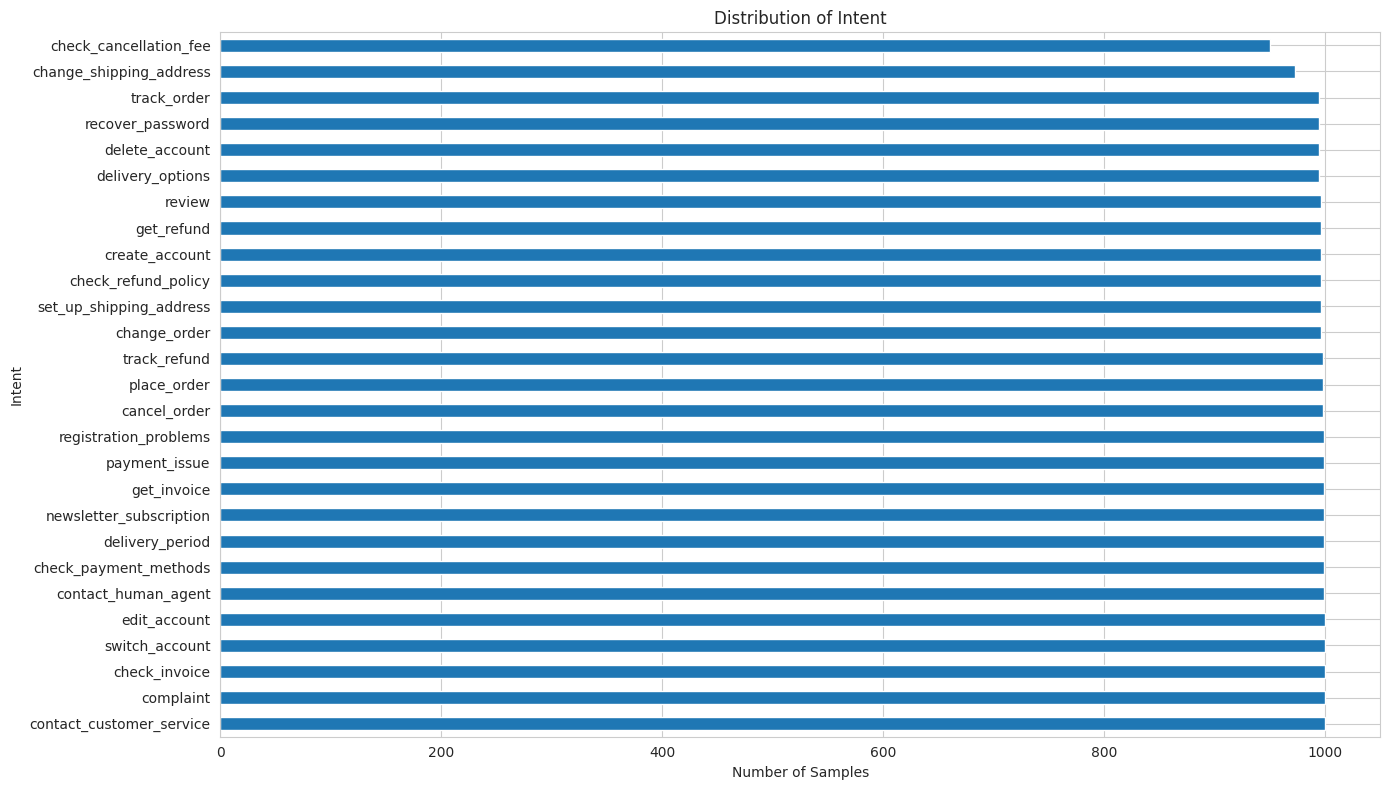

In [9]:
# Visualize intent/label distribution if available
label_col = 'intent'

fig, ax = plt.subplots(figsize=(14, 8))
train_df[label_col].value_counts().plot(kind='barh', ax=ax)
ax.set_xlabel('Number of Samples')
ax.set_ylabel(label_col.capitalize())
ax.set_title(f'Distribution of {label_col.capitalize()}')
plt.tight_layout()
plt.show()

## Text Analysis

In [10]:
# Calculate text statistics
train_df['word_count'] = train_df[text_col].str.split().str.len()

print(f"Text statistics:")
print(f"\nText length (characters):")
print(train_df['text_length'].describe())
print(f"\nWord count:")
print(train_df['word_count'].describe())

Text statistics:

Text length (characters):
count    26872.000000
mean        46.889513
std         10.897578
min          6.000000
25%         40.000000
50%         48.000000
75%         55.000000
max         92.000000
Name: text_length, dtype: float64

Word count:
count    26872.000000
mean         8.690979
std          2.605004
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         16.000000
Name: word_count, dtype: float64


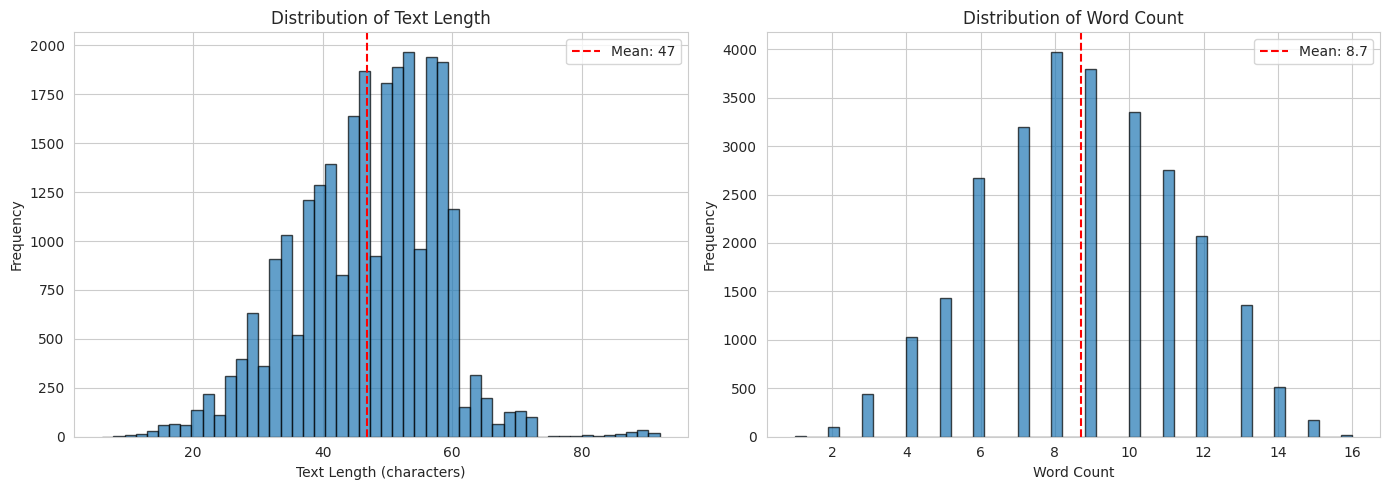

In [11]:
# Visualize text statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length distribution
axes[0].hist(train_df['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['text_length'].mean():.0f}")
axes[0].legend()

# Word count distribution
axes[1].hist(train_df['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count')
axes[1].axvline(train_df['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['word_count'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Sample some texts
print("Sample texts from the dataset:\n")
for i in range(5):
    print(f"Sample {i+1}:")
    print(f"  Text: {train_df[text_col].iloc[i]}")
    if 'intent' in train_df.columns:
        print(f"  Intent: {train_df['intent'].iloc[i]}")
    elif 'label' in train_df.columns:
        print(f"  Label: {train_df['label'].iloc[i]}")
    print()

Sample texts from the dataset:

Sample 1:
  Text: question about cancelling order {{Order Number}}
  Intent: cancel_order

Sample 2:
  Text: i have a question about cancelling oorder {{Order Number}}
  Intent: cancel_order

Sample 3:
  Text: i need help cancelling puchase {{Order Number}}
  Intent: cancel_order

Sample 4:
  Text: I need to cancel purchase {{Order Number}}
  Intent: cancel_order

Sample 5:
  Text: I cannot afford this order, cancel purchase {{Order Number}}
  Intent: cancel_order



## Class Balance Analysis

In [13]:
label_col = 'intent'

label_counts = train_df[label_col].value_counts()
imbalance_ratio = label_counts.max() / label_counts.min()

print(f"Class balance analysis:")
print(f"  Total classes: {train_df[label_col].nunique()}")
print(f"  Samples per class (min): {label_counts.min()}")
print(f"  Samples per class (max): {label_counts.max()}")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}")

# Check for class imbalance
if imbalance_ratio > 10:
    print("\n⚠️  WARNING: Significant class imbalance detected!")
else:
    print("\n✓ Class distribution appears relatively balanced.")

Class balance analysis:
  Total classes: 27
  Samples per class (min): 950
  Samples per class (max): 1000
  Imbalance ratio: 1.05

✓ Class distribution appears relatively balanced.


## Data Split Analysis

In [14]:
# Compare splits
split_stats = {}
for split_name in dataset.keys():
    split_df = pd.DataFrame(dataset[split_name])
    label_col_temp = None
    if 'intent' in split_df.columns:
        label_col_temp = 'intent'
    elif 'label' in split_df.columns:
        label_col_temp = 'label'
    
    split_stats[split_name] = {
        'num_samples': len(split_df),
        'num_features': len(split_df.columns),
        'avg_text_length': split_df[text_col].str.len().mean() if text_col in split_df.columns else None,
        'num_classes': split_df[label_col_temp].nunique() if label_col_temp else None
    }

split_df_summary = pd.DataFrame(split_stats).T
print("Split statistics:")
print(split_df_summary)

Split statistics:
       num_samples  num_features  avg_text_length  num_classes
train      26872.0           5.0        46.889513         27.0


## Summary and Key Findings

In [15]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nDataset: Bitext Customer Support LLM Chatbot Training")
print(f"Total training samples: {len(train_df)}")
print(f"Number of features: {len(train_df.columns)}")
print(f"\nText statistics:")
print(f"  Average text length: {train_df['text_length'].mean():.0f} characters")
print(f"  Average word count: {train_df['word_count'].mean():.1f} words")
print(f"  Min text length: {train_df['text_length'].min()} characters")
print(f"  Max text length: {train_df['text_length'].max()} characters")

label_col = 'intent'
label_counts = train_df[label_col].value_counts()
print(f"\nIntent/Classification:")
print(f"  Number of classes: {train_df[label_col].nunique()}")
print(f"  Most common: {label_counts.index[0]} ({label_counts.values[0]} samples)")
print(f"  Least common: {label_counts.index[-1]} ({label_counts.values[-1]} samples)")

print(f"\nMissing values: {train_df.isnull().sum().sum()}")
print("="*60)

DATASET SUMMARY

Dataset: Bitext Customer Support LLM Chatbot Training
Total training samples: 26872
Number of features: 7

Text statistics:
  Average text length: 47 characters
  Average word count: 8.7 words
  Min text length: 6 characters
  Max text length: 92 characters

Intent/Classification:
  Number of classes: 27
  Most common: contact_customer_service (1000 samples)
  Least common: check_cancellation_fee (950 samples)

Missing values: 0
